# Rafael TCC - Projeto 04
## Análise Estatística Descritiva: Linhagens, Pedigree e Criatórios
Mapeamento do impacto de criatórios, patriarcas e troncos genéticos no preço do sêmen Nelore (ANCP)

### Bibliotecas

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

print("Bibliotecas carregadas com sucesso!")

Bibliotecas carregadas com sucesso!


### Leitura das Bases e Cruzamento (Merge)

In [2]:
# 1. Carregar a base de touros válidos da ANCP (N = 115)
programa = 'ANCP'
df_ancp = pd.read_csv(f'Dados/CSV/NeloreCRV_{programa}_valido.csv')

# 2. Carregar dados gerais contendo a genealogia (criador, linhagem, pai, avô paterno e avô materno)
df_geral = pd.read_csv('Dados/CSV/NeloreCRV_Dados_Gerais.csv')

# 3. Cruzamento por código CRV
cols_genealogia = ['crv_code', 'criador', 'proprietario', 'linhagem', 'pai', 'avo_paterno', 'avo_materno']
df_linhagens = pd.merge(
    df_ancp, 
    df_geral[cols_genealogia], 
    left_on='CRV_COD', 
    right_on='crv_code', 
    how='inner'
)

print("=" * 80)
print(f"BASE INTEGRADA COM SUCESSO: N = {len(df_linhagens)} touros ANCP mapeados")
print("=" * 80)
display(df_linhagens[['CRV_COD', 'NOME', 'SEMEM', 'criador', 'linhagem', 'pai', 'avo_materno']].head())

BASE INTEGRADA COM SUCESSO: N = 115 touros ANCP mapeados


,CRV_COD,NOME,SEMEM,criador,linhagem,pai,avo_materno
0,9006.0,ACE FC CACHOEIRAO,33.9,Fazenda Cachoeirão,SHERLOCK MAT x REM ARMADOR,SHERLOCK MAT,REM ARMADOR
1,9031.0,ALIADO JL DA BAMA,31.2,Fazenda BAMA,HERDEIRO DO IZ x RAÍ DA MN,HERDEIRO DO IZ,RAÍ DA MN
2,9749.0,1440 DE NAVIRAI,36.5,Chácara Naviraí,REM GALO x NAVIRAI HORARIO,REM GALO,NAVIRAI HORARIO
3,9073.0,ARACUÃ DA MDLO,33.9,Fazenda Modelo,BELO J MACHADO x AVESSO DA BELA,BELO J MACHADO,AVESSO DA BELA
4,9862.0,C2503 DA S.NICE,31.2,Fazenda Santa Nice,RAJAN COL x BARAN TRADIÇÃO,RAJAN COL,BARAN TRADIÇÃO


### Análise Descritiva por Criador (Fazenda / Criatório de Origem)

In [3]:
# Média Geral do Catálogo como Benchmark de Referência
media_geral = df_linhagens['SEMEM'].mean()
print("=" * 115)
print(f"ANÁLISE DE CRIATÓRIOS: BENCHMARK GERAL (R$ {media_geral:.2f}) & ÁGIO (COM vs. SEM)")
print("=" * 115)

criadores_resumo = []

for criador, g in df_linhagens.groupby('criador'):
    n_com = len(g)
    if n_com >= 3:
        com = g['SEMEM']
        sem = df_linhagens[df_linhagens['criador'] != criador]['SEMEM']
        
        # Teste t de Student para duas amostras independentes (COM vs. SEM)
        t_stat, p_val = stats.ttest_ind(com, sem, equal_var=False)
        
        # 1. Comparação com a Média Geral (R$ 32,40)
        dif_geral_reais = com.mean() - media_geral
        dif_geral_pct = ((com.mean() / media_geral) - 1) * 100
        
        # 2. Comparação COM vs. SEM (Ágio Clássico)
        agio_reais = com.mean() - sem.mean()
        agio_pct = ((com.mean() / sem.mean()) - 1) * 100
        
        criadores_resumo.append({
            'Criador': criador,
            'N_Touros': n_com,
            '% Catálogo': round(n_com / len(df_linhagens) * 100, 1),
            'Preço Médio (R$)': round(com.mean(), 2),
            'Mediana (R$)': round(com.median(), 2),
            'Dif. vs. Geral (R$)': round(dif_geral_reais, 2),
            'Var. vs. Geral (%)': round(dif_geral_pct, 1),
            'Preço Médio SEM (R$)': round(sem.mean(), 2),
            'Ágio COM/SEM (R$)': round(agio_reais, 2),
            'p-valor': round(p_val, 4)
        })

df_criadores = pd.DataFrame(criadores_resumo).sort_values(by='Preço Médio (R$)', ascending=False).reset_index(drop=True)

# Adicionar formatação de significância
def rotulo_p(p):
    if p < 0.01: return '*** (Signif. 1%)'
    if p < 0.05: return '** (Signif. 5%)'
    if p < 0.10: return '* (Signif. 10%)'
    return 'Não significativo'

df_criadores['Significância'] = df_criadores['p-valor'].apply(rotulo_p)

display(df_criadores)


ANÁLISE DE CRIATÓRIOS: BENCHMARK GERAL (R$ 32.40) & ÁGIO (COM vs. SEM)


,Criador,N_Touros,% Catálogo,Preço Médio (R$),Mediana (R$),Dif. vs. Geral (R$),Var. vs. Geral (%),Preço Médio SEM (R$),Ágio COM/SEM (R$),p-valor,Significância
0,EAO Agropecuária,5,4.3,41.06,34.90,8.66,26.7,32.01,9.05,0.1850,Não significativo
1,Colonial Agropecuária,17,14.8,32.79,33.90,0.39,1.2,32.33,0.45,0.8396,Não significativo
2,Chácara Naviraí,3,2.6,32.60,36.50,0.20,0.6,32.40,0.20,0.9632,Não significativo
3,Fazenda Modelo,7,6.1,32.49,33.90,0.08,0.3,32.40,0.09,0.9754,Não significativo
4,Instituto de Zootecnia de Sertãozinho,4,3.5,32.47,32.55,0.07,0.2,32.40,0.08,0.9796,Não significativo
5,Katayama Pecuária,14,12.2,32.30,31.20,-0.10,-0.3,32.41,-0.11,0.9436,Não significativo
6,Fazenda Santa Nice,5,4.3,32.28,31.20,-0.12,-0.4,32.41,-0.13,0.8943,Não significativo
7,Rancho da Matinha,4,3.5,32.25,33.85,-0.15,-0.5,32.41,-0.16,0.9595,Não significativo
8,Fazenda Mundo Novo,4,3.5,32.22,29.35,-0.18,-0.5,32.41,-0.18,0.9728,Não significativo
9,Genética Aditiva Agropecuária,6,5.2,28.38,32.55,-4.02,-12.4,32.62,-4.24,0.2328,Não significativo


###  Análise Descritiva de Pais e Avôs Maternos Líderes

In [4]:
print("=" * 80)
print("PRINCIPAIS PAIS NA BATERIA ANCP (N >= 2 filhos)")
print("=" * 80)
tabela_pais = df_linhagens.groupby('pai').agg(
    N_Filhos=('SEMEM', 'count'),
    Preco_Medio=('SEMEM', 'mean'),
    Preco_Mediano=('SEMEM', 'median')
).query('N_Filhos >= 2').sort_values(by=['Preco_Medio', 'N_Filhos'], ascending=False).round(2).reset_index()
display(tabela_pais)

print("\n" + "=" * 80)
print("PRINCIPAIS AVÔS MATERNOS NA BATERIA ANCP (N >= 3 netos)")
print("=" * 80)
tabela_avos = df_linhagens.groupby('avo_materno').agg(
    N_Netos=('SEMEM', 'count'),
    Preco_Medio=('SEMEM', 'mean'),
    Preco_Mediano=('SEMEM', 'median')
).query('N_Netos >= 3').sort_values(by=['Preco_Medio', 'N_Netos'], ascending=False).round(2).reset_index()
display(tabela_avos)

PRINCIPAIS PAIS NA BATERIA ANCP (N >= 2 filhos)


,pai,N_Filhos,Preco_Medio,Preco_Mediano
0,REM GARANTIDO,3,42.03,34.90
1,KOCHI KA,2,37.70,37.70
2,CAMPEÃO DA MN,3,37.70,33.90
3,REM ARMADOR,5,36.98,33.90
4,EL ZORRERO SINO,2,35.65,35.65
5,QUICKMAN COL,4,34.52,35.20
6,BELO J MACHADO,2,33.90,33.90
7,OPERÁRIO COL,2,33.90,33.90
8,REM HERMOSO,3,33.87,33.90
9,REM VOKOLO,3,32.90,33.90



PRINCIPAIS AVÔS MATERNOS NA BATERIA ANCP (N >= 3 netos)


,avo_materno,N_Netos,Preco_Medio,Preco_Mediano
0,BACKUP,7,36.60,33.9
1,REM ARMADOR,14,35.62,33.9
2,REM USP,7,34.44,34.9
3,GANGES COL,5,31.72,31.2
4,GANGLIO KA,3,28.10,31.2


### Mapeamento dos Grandes Troncos / Famílias de Linhagens

In [5]:
# Identificar a presença dos grandes troncos da raça Nelore presentes no pedigree
# (paterno, avô materno, avô paterno ou no afixo do nome)
troncos = {
    'TRONCO_REM': lambda r: 1 if any('REM' in str(x).upper() for x in [r['linhagem'], r['pai'], r['avo_paterno'], r['avo_materno'], r['NOME']]) else 0,
    'TRONCO_MATINHA': lambda r: 1 if any(('MAT' in str(x).upper() or 'MATINHA' in str(x).upper()) for x in [r['linhagem'], r['pai'], r['avo_paterno'], r['avo_materno'], r['NOME']]) else 0,
    'TRONCO_COLONIAL': lambda r: 1 if any(('COL' in str(x).upper() or 'COLONIAL' in str(x).upper()) for x in [r['linhagem'], r['pai'], r['avo_paterno'], r['avo_materno'], r['NOME']]) else 0,
    'TRONCO_LEMGRUBER_MN': lambda r: 1 if any((' MN' in str(x).upper() or 'MUNDO NOVO' in str(x).upper() or 'LEMGRUBER' in str(x).upper()) for x in [r['linhagem'], r['pai'], r['avo_paterno'], r['avo_materno'], r['NOME']]) else 0,
    'TRONCO_IZ': lambda r: 1 if any(('IZ' in str(x).upper() or 'SERTÃOZINHO' in str(x).upper()) for x in [r['linhagem'], r['pai'], r['avo_paterno'], r['avo_materno'], r['NOME']]) else 0,
    'TRONCO_NAVIRAI': lambda r: 1 if any(('NAVIRAI' in str(x).upper() or 'NAVIRAÍ' in str(x).upper()) for x in [r['linhagem'], r['pai'], r['avo_paterno'], r['avo_materno'], r['NOME']]) else 0,
    'TRONCO_EAO': lambda r: 1 if any('EAO' in str(x).upper() for x in [r['linhagem'], r['pai'], r['avo_paterno'], r['avo_materno'], r['NOME'], r['criador']]) else 0
}

# Criar as colunas binárias indicadoras
for nome, func in troncos.items():
    df_linhagens[nome] = df_linhagens.apply(func, axis=1)

# Calcular tabela de ágio dos troncos genéticos
troncos_resumo = []
for nome in troncos.keys():
    com = df_linhagens[df_linhagens[nome] == 1]['SEMEM']
    sem = df_linhagens[df_linhagens[nome] == 0]['SEMEM']
    
    if len(com) >= 3 and len(sem) >= 3:
        t_stat, p_val = stats.ttest_ind(com, sem, equal_var=False)
        troncos_resumo.append({
            'Tronco_Linhagem': nome.replace('TRONCO_', ''),
            'N_Touros': len(com),
            '% Touros': round(len(com) / len(df_linhagens) * 100, 1),
            'Preço Médio COM (R$)': round(com.mean(), 2),
            'Preço Médio SEM (R$)': round(sem.mean(), 2),
            'Mediana COM (R$)': round(com.median(), 2),
            'Mediana SEM (R$)': round(sem.median(), 2),
            'Ágio (R$)': round(com.mean() - sem.mean(), 2),
            'Ágio (%)': round(((com.mean() / sem.mean()) - 1) * 100, 1),
            'p-valor': round(p_val, 4)
        })

df_troncos = pd.DataFrame(troncos_resumo).sort_values(by='Ágio (R$)', ascending=False).reset_index(drop=True)
df_troncos['Significância'] = df_troncos['p-valor'].apply(rotulo_p)

print("=" * 100)
print("RANKING DE VALORIZAÇÃO DOS GRANDES TRONCOS GENÉTICOS NO NELORE")
print("=" * 100)
display(df_troncos)

RANKING DE VALORIZAÇÃO DOS GRANDES TRONCOS GENÉTICOS NO NELORE


,Tronco_Linhagem,N_Touros,% Touros,Preço Médio COM (R$),Preço Médio SEM (R$),Mediana COM (R$),Mediana SEM (R$),Ágio (R$),Ágio (%),p-valor,Significância
0,EAO,5,4.3,41.06,32.01,34.9,31.2,9.05,28.3,0.1850,Não significativo
1,NAVIRAI,3,2.6,34.73,32.34,36.5,31.2,2.39,7.4,0.3059,Não significativo
2,REM,67,58.3,32.60,32.12,31.2,31.2,0.49,1.5,0.6983,Não significativo
3,LEMGRUBER_MN,22,19.1,32.70,32.33,31.2,31.2,0.36,1.1,0.8140,Não significativo
4,MATINHA,18,15.7,32.57,32.37,31.8,31.2,0.20,0.6,0.9039,Não significativo
5,COLONIAL,29,25.2,32.53,32.36,33.9,31.2,0.18,0.6,0.9077,Não significativo
6,IZ,13,11.3,31.18,32.56,31.2,31.2,-1.37,-4.2,0.3838,Não significativo


### Visualização - Gráficos de barras horizontais

#### Ágio de preço da dose por criatório (com vs. Sem)

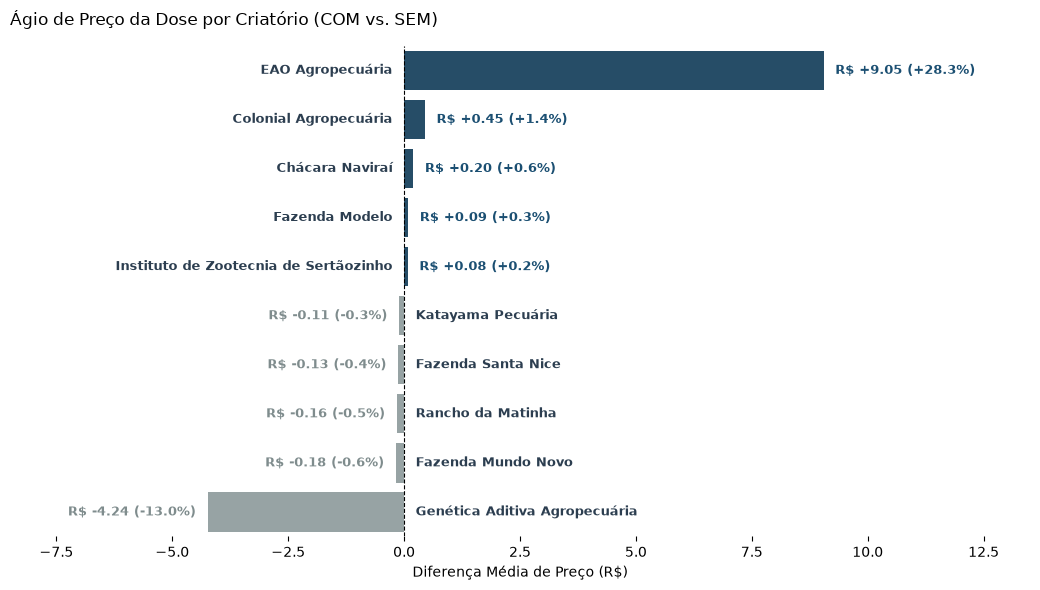

In [10]:
# Identifica o nome exato da coluna de ágio em df_criadores
col_criador_agio = 'Ágio COM/SEM (R$)' if 'Ágio COM/SEM (R$)' in df_criadores.columns else 'Ágio (R$)'

df_criadores_plot = df_criadores.sort_values(by=col_criador_agio, ascending=False).reset_index(drop=True)

plt.figure(figsize=(10.5, 6))

cores_criador = ['#1b4f72' if v > 0 else '#95a5a6' for v in df_criadores_plot[col_criador_agio]]

ax1 = sns.barplot(
    data=df_criadores_plot, 
    x=col_criador_agio, 
    y='Criador', 
    palette=cores_criador, 
    hue='Criador', 
    legend=False
)

ax1.yaxis.set_visible(False)
ax1.axvline(0, color='black', linewidth=0.8, linestyle='--')

for i, row in df_criadores_plot.iterrows():
    nome = row['Criador']
    agio_rs = row[col_criador_agio]
    
    # Obtém ou calcula o percentual de ágio COM vs. SEM
    if 'Ágio (%)' in row:
        agio_pct = row['Ágio (%)']
    elif 'Var. vs. Geral (%)' in row and 'Preço Médio SEM (R$)' in row:
        agio_pct = ((row['Preço Médio (R$)'] / row['Preço Médio SEM (R$)']) - 1) * 100
    else:
        agio_pct = 0.0
        
    texto_valor = f"R$ {agio_rs:+.2f} ({agio_pct:+.1f}%)"
    cor_valor = '#1b4f72' if agio_rs > 0 else '#7f8c8d'
    
    if agio_rs >= 0:
        # Rótulo à ESQUERDA da linha zero
        ax1.text(
            -0.25, i, nome, 
            va='center', ha='right', 
            fontsize=9.5, fontweight='bold', color='#2c3e50'
        )
        # Valor à DIREITA da ponta da barra
        ax1.text(
            agio_rs + 0.25, i, texto_valor, 
            va='center', ha='left', 
            fontsize=9, fontweight='bold', color=cor_valor
        )
    else:
        # Rótulo à DIREITA da linha zero
        ax1.text(
            0.25, i, nome, 
            va='center', ha='left', 
            fontsize=9.5, fontweight='bold', color='#2c3e50'
        )
        # Valor à ESQUERDA da ponta da barra
        ax1.text(
            agio_rs - 0.25, i, texto_valor, 
            va='center', ha='right', 
            fontsize=9, fontweight='bold', color=cor_valor
        )

ax1.set_title('Ágio de Preço da Dose por Criatório (COM vs. SEM)', fontsize=12, loc='left', pad=15)
ax1.set_xlabel('Diferença Média de Preço (R$)', fontsize=10)
ax1.set_ylabel('')
ax1.set_xlim(-8.5, 13.5)

sns.despine(left=True, bottom=True, top=True, right=True)
plt.tight_layout()
plt.show()

#### Ágio de preço por tronco de linhagem ancestral

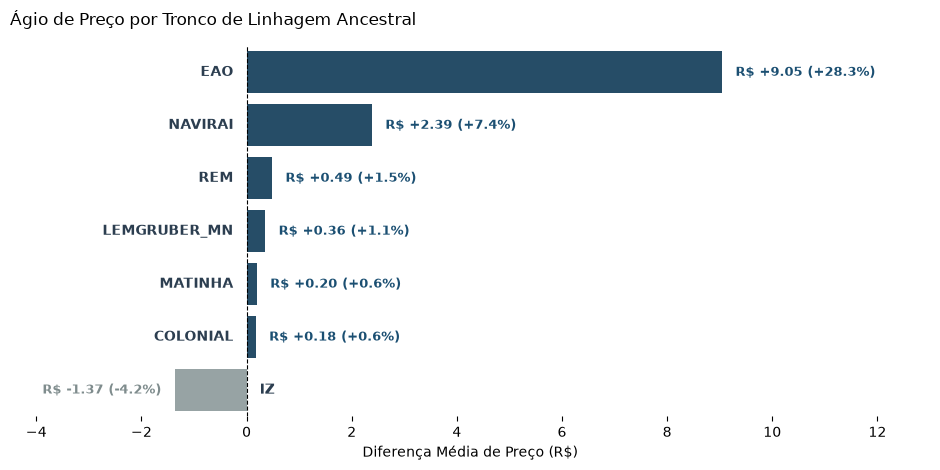

In [9]:
col_tronco_agio = 'Ágio (R$)' if 'Ágio (R$)' in df_troncos.columns else 'Ágio COM/SEM (R$)'

df_troncos_plot = df_troncos.sort_values(by=col_tronco_agio, ascending=False).reset_index(drop=True)

plt.figure(figsize=(9.5, 4.8))

cores_tronco = ['#1b4f72' if v > 0 else '#95a5a6' for v in df_troncos_plot[col_tronco_agio]]

ax2 = sns.barplot(
    data=df_troncos_plot, 
    x=col_tronco_agio, 
    y='Tronco_Linhagem', 
    palette=cores_tronco, 
    hue='Tronco_Linhagem', 
    legend=False
)

ax2.yaxis.set_visible(False)
ax2.axvline(0, color='black', linewidth=0.8, linestyle='--')

for i, row in df_troncos_plot.iterrows():
    nome = row['Tronco_Linhagem']
    agio_rs = row[col_tronco_agio]
    agio_pct = row['Ágio (%)'] if 'Ágio (%)' in row else 0.0
    
    texto_valor = f"R$ {agio_rs:+.2f} ({agio_pct:+.1f}%)"
    cor_valor = '#1b4f72' if agio_rs > 0 else '#7f8c8d'
    
    if agio_rs >= 0:
        # Rótulo à ESQUERDA da linha zero
        ax2.text(
            -0.25, i, nome, 
            va='center', ha='right', 
            fontsize=10, fontweight='bold', color='#2c3e50'
        )
        # Valor à DIREITA da ponta da barra
        ax2.text(
            agio_rs + 0.25, i, texto_valor, 
            va='center', ha='left', 
            fontsize=9, fontweight='bold', color=cor_valor
        )
    else:
        # Rótulo à DIREITA da linha zero
        ax2.text(
            0.25, i, nome, 
            va='center', ha='left', 
            fontsize=10, fontweight='bold', color='#2c3e50'
        )
        # Valor à ESQUERDA da ponta da barra
        ax2.text(
            agio_rs - 0.25, i, texto_valor, 
            va='center', ha='right', 
            fontsize=9, fontweight='bold', color=cor_valor
        )

ax2.set_title('Ágio de Preço por Tronco de Linhagem Ancestral', fontsize=12, loc='left', pad=15)
ax2.set_xlabel('Diferença Média de Preço (R$)', fontsize=10)
ax2.set_ylabel('')
ax2.set_xlim(-4.5, 13.0)

sns.despine(left=True, bottom=True, top=True, right=True)
plt.tight_layout()
plt.show()
